In [ ]:
print("필수 환경 설정 중...")
!pip install mediapipe==0.10.14 opencv-python-headless==4.10.0.84 pillow matplotlib > /dev/null 2>&1
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1
!rm ~/.cache/matplotlib -rf > /dev/null 2>&1
print("설치 완료!")

필수 환경 설정 중...
설치 완료!


In [ ]:
print("필수 환경 설정 중...")
!pip uninstall tensorflow tensorflow-gpu -y -q
!pip install mediapipe==0.10.14 opencv-python-headless==4.10.0.84 pillow matplotlib xgboost -q
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1
!rm ~/.cache/matplotlib -rf > /dev/null 2>&1
print("설치 완료!")

필수 환경 설정 중...
설치 완료!


In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os, io, joblib, warnings, subprocess
from collections import deque, Counter
from google.colab.patches import cv2_imshow
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import ImageFont, ImageDraw, Image
from IPython.display import HTML, display
from base64 import b64encode
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (matplotlib)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family=fm.FontProperties(fname=font_path).get_name())
plt.rcParams['axes.unicode_minus'] = False

mp_pose    = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

print("환경 설정 완료!")

환경 설정 완료!


In [ ]:
from PIL import ImageFont, ImageDraw, Image

LABEL_MAP = {
    0: '올바른 스쿼트',    1: '얕은 스쿼트',
    2: '앞으로 기울어진 스쿼트', 3: '무릎 안쪽 꺾임',
    4: '발뒤꿈치 들림',    5: '비대칭 스쿼트',
}
FEEDBACK_MAP = {
    0: '완벽한 스쿼트입니다! 자세를 유지하세요.',
    1: '더 깊이 내려가세요. 무릎이 90도 이상 굽혀져야 합니다.',
    2: '상체를 세워주세요. 코어에 힘을 주고 가슴을 앞으로 내미세요.',
    3: '무릎이 안쪽으로 꺾이고 있습니다. 발끝 방향으로 무릎을 밀어주세요.',
    4: '발뒤꿈치가 들리고 있습니다. 발바닥 전체를 바닥에 붙이세요.',
    5: '좌우 균형이 맞지 않습니다. 양쪽 체중을 균등하게 분배하세요.',
}
COLOR_MAP = {
    0:(0,200,0), 1:(0,220,220), 2:(0,140,255),
    3:(0,0,255), 4:(200,0,200), 5:(255,100,0),
}
FEATURE_COLS = [
    'knee_angle_left','knee_angle_right',
    'hip_angle_left', 'hip_angle_right',
    'ankle_angle_left','ankle_angle_right',
    'knee_angle_avg', 'hip_angle_avg',
    'ankle_angle_avg','knee_asymmetry','heel_diff',
]

def put_korean_text(frame, text, pos, font_size=20, color=(255,255,255)):
    img_pil = Image.fromarray(frame)
    draw    = ImageDraw.Draw(img_pil)
    font    = ImageFont.truetype('/usr/share/fonts/truetype/nanum/NanumGothic.ttf', font_size)
    draw.text(pos, text, font=font, fill=color)
    return np.array(img_pil)

def calc_angle(a, b, c):
    a = np.array(a, dtype=float)[:2]
    b = np.array(b, dtype=float)[:2]
    c = np.array(c, dtype=float)[:2]
    ba = a - b
    bc = c - b
    cos_v = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    return float(np.degrees(np.arccos(np.clip(cos_v, -1.0, 1.0))))

def get_lm(landmarks, name, w=1, h=1):
    lm = landmarks[mp_pose.PoseLandmark[name].value]
    return np.array([lm.x * w, lm.y * h])

def extract_angles(lm, w=1, h=1):
    try:
        vis_l = lm[mp_pose.PoseLandmark['LEFT_KNEE'].value].visibility
        vis_r = lm[mp_pose.PoseLandmark['RIGHT_KNEE'].value].visibility
        side  = 'LEFT' if vis_l >= vis_r else 'RIGHT'
        opp   = 'RIGHT' if side == 'LEFT' else 'LEFT'

        sh  = get_lm(lm, f'{side}_SHOULDER', w, h)
        hip = get_lm(lm, f'{side}_HIP',      w, h)
        kn  = get_lm(lm, f'{side}_KNEE',     w, h)
        an  = get_lm(lm, f'{side}_ANKLE',    w, h)
        ft  = get_lm(lm, f'{side}_FOOT_INDEX', w, h)
        he  = get_lm(lm, f'{side}_HEEL',     w, h)

        if kn[1] < hip[1]:
            print('  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환')
            kn, hip = hip, kn

        spine_top = (sh + hip) / 2
        k_ang = calc_angle(hip, kn, an)
        h_ang = calc_angle(spine_top, hip, kn)
        a_ang = calc_angle(kn, an, ft)

        try:
            kn2     = get_lm(lm, f'{opp}_KNEE',  w, h)
            hi2     = get_lm(lm, f'{opp}_HIP',   w, h)
            an2     = get_lm(lm, f'{opp}_ANKLE', w, h)
            k2      = calc_angle(hi2, kn2, an2)
            opp_vis = lm[mp_pose.PoseLandmark[f'{opp}_KNEE'].value].visibility
            asym    = abs(k_ang - k2) if opp_vis > 0.7 else 0.0
        except:
            k2   = k_ang
            asym = 0.0

        print(f'  [디버그] side={side}, 무릎={k_ang:.1f}, 엉덩이={h_ang:.1f}, 발목={a_ang:.1f}')

        return {
            'knee_angle_left':   round(k_ang, 2),
            'knee_angle_right':  round(k2,    2),
            'hip_angle_left':    round(h_ang, 2),
            'hip_angle_right':   round(h_ang, 2),
            'ankle_angle_left':  round(a_ang, 2),
            'ankle_angle_right': round(a_ang, 2),
            'knee_angle_avg':    round(k_ang, 2),
            'hip_angle_avg':     round(h_ang, 2),
            'ankle_angle_avg':   round(a_ang, 2),
            'knee_asymmetry':    round(asym,  2),
            'heel_diff':         round(abs(he[1] - an[1]), 4),
        }
    except Exception as e:
        print(f'각도 추출 오류: {e}')
        return None

def extract_metrics(landmarks, w, h):
    def p(i): return np.array([landmarks[i].x*w, landmarks[i].y*h])
    vis_l = landmarks[25].visibility
    vis_r = landmarks[26].visibility
    if vis_l >= vis_r:
        sh, hip, knee, ankle, foot = p(11), p(23), p(25), p(27), p(31)
    else:
        sh, hip, knee, ankle, foot = p(12), p(24), p(26), p(28), p(32)

    if knee[1] < hip[1]:
        knee, hip = hip, knee

    spine_top = (sh + hip) / 2
    lk = calc_angle(hip, knee, ankle)
    sp = calc_angle(spine_top, hip, knee)
    la = calc_angle(knee, ankle, foot)
    ki = max(knee[0] - ankle[0], 0) / (abs(hip[0] - ankle[0]) + 1e-6)
    return {'lk':lk, 'rk':lk, 'sp':sp, 'la':la, 'ra':la, 'ki':ki, 'sym':0.0}

def rule_classify(angles):
    k, h  = angles['knee_angle_avg'], angles['hip_angle_avg']
    asym  = angles['knee_asymmetry']
    heel  = angles['heel_diff']

    if asym > 15:          return 5
    if heel > 0.05:        return 4
    if h < 60 or h > 120: return 2
    if asym > 10:          return 3
    if k < 50:             return 1
    if 50 <= k <= 80:      return 0
    if 80 < k <= 120:      return 1
    if k >= 150:           return -1
    return 1

def judge_squat_logic(m):
    fb, labels = [], []
    avg_k = (m['lk'] + m['rk']) / 2

    if avg_k < 50:     labels.append(1); fb.append(f'얕은 스쿼트({avg_k:.1f}도)')
    if avg_k > 80:     labels.append(1); fb.append(f'너무 깊음({avg_k:.1f}도)')
    if m['sp'] < 60:   labels.append(2); fb.append(f'상체 숙여짐({m["sp"]:.1f}도)')
    if m['sp'] > 120:  labels.append(2); fb.append(f'상체 뒤로 기울어짐({m["sp"]:.1f}도)')
    if m['ki'] > 0.15: labels.append(3); fb.append('무릎 꺾임')
    if m['la'] < 50 or m['ra'] < 50: labels.append(4); fb.append('뒤꿈치 들림')
    if m['sym'] > 15:  labels.append(5); fb.append(f'비대칭({m["sym"]:.1f}도)')

    if not labels and 50 <= avg_k <= 80:
        return 0, '완벽'
    return (labels[0] if labels else -1), ', '.join(fb)

def calc_class_probabilities(m):
    avg_k  = (m['lk'] + m['rk']) / 2
    scores = {i: 0.0 for i in range(6)}

    if avg_k < 50:     scores[1] = min((50 - avg_k)  / 25.0, 1.0) * 3.0
    if avg_k > 80:     scores[1] = min((avg_k - 80)  / 35.0, 1.0) * 2.0
    if m['sp'] < 60:   scores[2] = min((60 - m['sp'])/ 30.0, 1.0) * 3.0
    if m['sp'] > 120:  scores[2] = min((m['sp']-120) / 30.0, 1.0) * 3.0
    if m['ki'] > 0.15: scores[3] = min((m['ki']-0.15)/ 0.2,  1.0) * 4.0
    heel_err = max(50 - m['la'], 50 - m['ra'], 0)
    if heel_err > 0:   scores[4] = min(heel_err / 20.0, 1.0) * 3.0
    if m['sym'] > 15:  scores[5] = min((m['sym']-15) / 20.0, 1.0) * 3.0

    base = 2.0
    if 50 <= avg_k <= 80 and 60 <= m['sp'] <= 120 and m['ki'] <= 0.15:
        base += 2.0
    scores[0] = max(base - sum(scores[i] for i in range(1,6)), 0.0)

    vals  = np.array(list(scores.values()))
    probs = np.exp(vals - vals.max())
    probs /= probs.sum()
    return {LABEL_MAP[i]: round(float(probs[i])*100, 1) for i in range(6)}

class SquatClassifier:
    def __init__(self, model_type='random_forest'):
        self.model = None; self.scaler = None
        self.model_type = model_type; self._load()
    def _load(self):
        mp_path = f'models/{self.model_type}.pkl'
        sc_path = f'models/{self.model_type}_scaler.pkl'
        if os.path.exists(mp_path):
            self.model  = joblib.load(mp_path)
            self.scaler = joblib.load(sc_path)
            print(f'✅ 모델 로드: {mp_path}')
        else:
            print('ℹ️ 저장된 모델 없음 → 룰 기반 분류 사용')
    def predict(self, angles):
        if self.model is None:
            return rule_classify(angles), 0.80
        try:
            X   = np.array([[angles[c] for c in FEATURE_COLS]])
            if self.model_type == 'xgboost': X = self.scaler.transform(X)
            lbl = int(self.model.predict(X)[0])
            return lbl, float(self.model.predict_proba(X)[0][lbl])
        except:
            return rule_classify(angles), 0.75

def draw_skeleton_and_angles(frame, pose_landmarks, angles):
    h, w = frame.shape[:2]
    mp_drawing.draw_landmarks(
        frame, pose_landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(0,0,220), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(0,220,0), thickness=2),
    )
    for lm_name, angle_key in [
        ('LEFT_KNEE',  'knee_angle_left'),
        ('RIGHT_KNEE', 'knee_angle_right'),
        ('LEFT_HIP',   'hip_angle_left'),
        ('RIGHT_HIP',  'hip_angle_right'),
    ]:
        lm_pt = pose_landmarks.landmark[mp_pose.PoseLandmark[lm_name].value]
        px, py = int(lm_pt.x * w), int(lm_pt.y * h)
        cv2.putText(frame, f'{angles[angle_key]:.0f}',
                    (px+5, py-10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (255,255,0), 1, cv2.LINE_AA)

def draw_overlay(frame, angles, label, conf):
    color = COLOR_MAP[label]
    name  = LABEL_MAP[label]
    fb    = FEEDBACK_MAP[label]

    overlay = frame.copy()
    cv2.rectangle(overlay, (0,0), (450,220), (0,0,0), -1)
    frame = cv2.addWeighted(overlay, 0.6, frame, 0.4, 0)

    frame = put_korean_text(frame, f'자세: {name}',                (10,20),  25, color)
    frame = put_korean_text(frame, f'신뢰도: {conf*100:.1f}%',     (10,55),  20, color)
    frame = put_korean_text(frame, f'무릎: {angles["knee_angle_avg"]:.1f}°  엉덩이: {angles["hip_angle_avg"]:.1f}°', (10,88))
    frame = put_korean_text(frame, f'발목: {angles["ankle_angle_avg"]:.1f}°  비대칭: {angles["knee_asymmetry"]:.1f}°', (10,118))
    frame = put_korean_text(frame, f'피드백: {fb[:22]}',           (10,155), 18, (0,220,255))
    if len(fb) > 22:
        frame = put_korean_text(frame, fb[22:],                    (10,180), 18, (0,220,255))
    return frame

print('✅ 셀2 완료!')

✅ 셀2 완료!


📂 이미지 파일을 선택하세요


Saving squat2.png to squat2 (1).png
✅ 모델 로드: models/random_forest.pkl

[분석 중] squat2 (1).png
  이름            x(px)  y(px)    vis
  ----------------------------------
  L_SHOULDER      396    287   1.00
  R_SHOULDER      219    287   1.00
  L_HIP           371    531   1.00
  R_HIP           257    536   1.00
  L_KNEE          485    514   1.00
  R_KNEE          136    513   0.99
  L_ANKLE         447    733   0.99
  R_ANKLE         177    738   1.00
  L_FOOT          488    783   0.99
  R_FOOT          123    781   0.99
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=LEFT, 무릎=77.6, 엉덩이=76.8, 발목=161.1


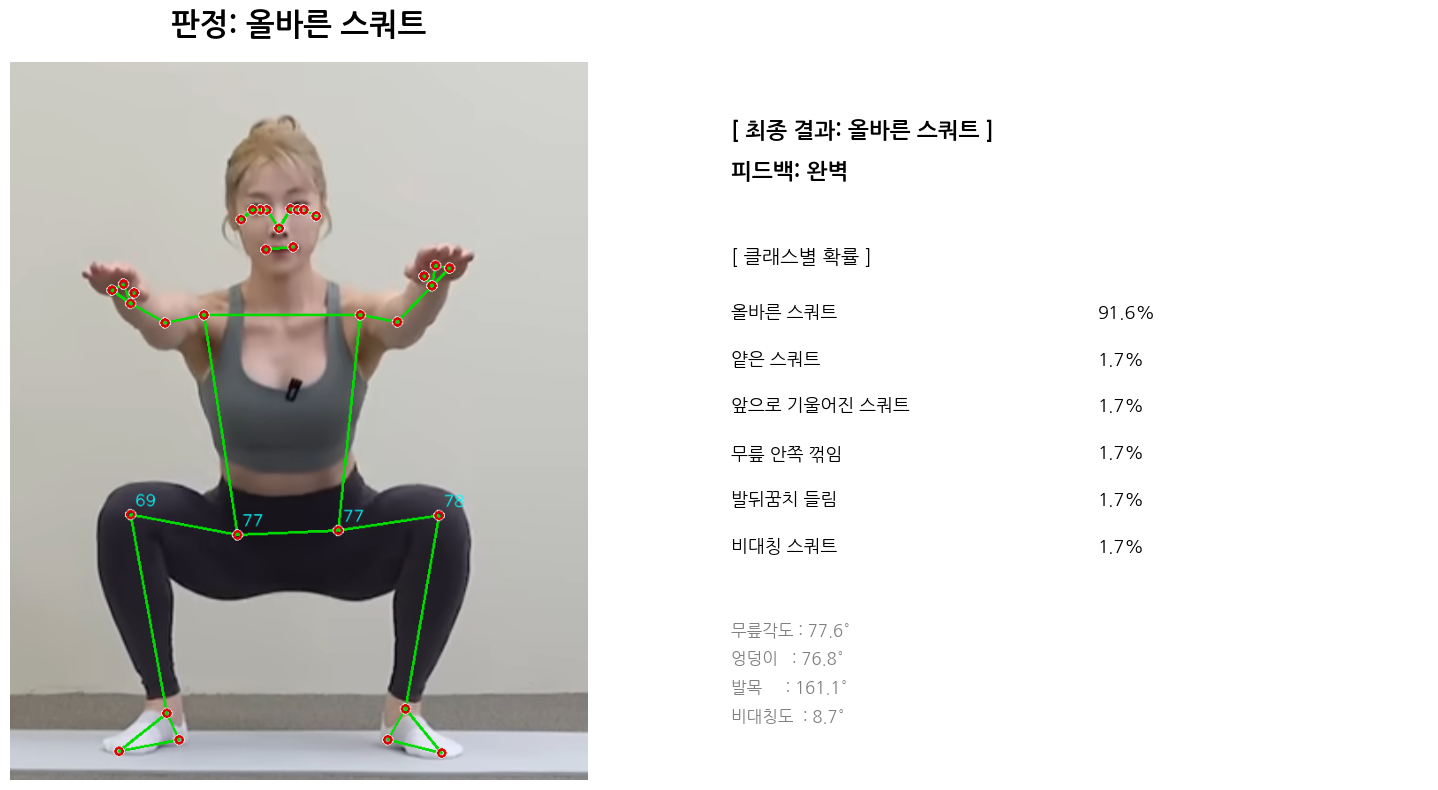

  ✅ 자세    : 올바른 스쿼트 (신뢰도 100.0%)
  📝 피드백  : 완벽한 스쿼트입니다! 자세를 유지하세요.
  📐 무릎각도 : 77.6°
  📐 엉덩이  : 76.8°
  📐 발목    : 161.1°
  ↔  비대칭도 : 8.7°


In [ ]:
print('📂 이미지 파일을 선택하세요')
uploaded = files.upload()

clf = SquatClassifier()

with mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.7, model_complexity=2) as pose:
    for filename, data in uploaded.items():
        print(f'\n[분석 중] {filename}')

        nparr = np.frombuffer(data, np.uint8)
        img   = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        h, w  = img.shape[:2]

        results = pose.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

        if not results.pose_landmarks:
            print('  ❌ 포즈 감지 실패 — 전신이 보이는 사진을 사용하세요')
            continue

        lm = results.pose_landmarks.landmark

        # ★ 랜드마크 좌표 디버그 출력
        check = {
            'L_SHOULDER':11, 'R_SHOULDER':12,
            'L_HIP':23,      'R_HIP':24,
            'L_KNEE':25,     'R_KNEE':26,
            'L_ANKLE':27,    'R_ANKLE':28,
            'L_FOOT':31,     'R_FOOT':32,
        }
        print(f'  {"이름":<12} {"x(px)":>6} {"y(px)":>6} {"vis":>6}')
        print(f'  {"-"*34}')
        for name, idx in check.items():
            px  = int(lm[idx].x * w)
            py  = int(lm[idx].y * h)
            vis = lm[idx].visibility
            print(f'  {name:<12} {px:>6} {py:>6} {vis:>6.2f}')

        angles = extract_angles(lm, w, h)
        m      = extract_metrics(lm, w, h)

        if not angles:
            print('  ⚠️ 각도 계산 실패')
            continue

        label, conf   = clf.predict(angles)
        idx, final_fb = judge_squat_logic(m)
        final_probs   = calc_class_probabilities(m)

        if idx == -1:
            final_label = '서있는 상태 (스쿼트 아님)'
        else:
            final_label = LABEL_MAP.get(idx, LABEL_MAP.get(label, '알 수 없음'))

        # 스켈레톤 + 각도 숫자 그리기
        ann_img = img.copy()
        mp_drawing.draw_landmarks(
            ann_img, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,0,220), thickness=2, circle_radius=4),
            mp_drawing.DrawingSpec(color=(0,220,0), thickness=2),
        )
        for lm_name, angle_key in [
            ('LEFT_KNEE',  'knee_angle_left'),
            ('RIGHT_KNEE', 'knee_angle_right'),
            ('LEFT_HIP',   'hip_angle_left'),
            ('RIGHT_HIP',  'hip_angle_right'),
        ]:
            lm_pt = results.pose_landmarks.landmark[mp_pose.PoseLandmark[lm_name].value]
            px, py = int(lm_pt.x * w), int(lm_pt.y * h)
            cv2.putText(ann_img, f'{angles[angle_key]:.0f}',
                        (px+5, py-10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255,255,0), 1, cv2.LINE_AA)

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                                 gridspec_kw={'width_ratios': [1.2, 1]})

        axes[0].imshow(cv2.cvtColor(ann_img, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'판정: {final_label}', fontsize=22, fontweight='bold', pad=20)
        axes[0].axis('off')

        axes[1].axis('off')
        axes[1].text(0.05, 0.92,
                     f'[ 최종 결과: {final_label} ]\n피드백: {final_fb if final_fb else "완벽"}',
                     fontsize=16, linespacing=2.0, va='top', fontweight='bold')
        axes[1].text(0.05, 0.72, '[ 클래스별 확률 ]', fontsize=14)

        for i, (lbl_name, prob) in enumerate(final_probs.items()):
            y = 0.65 - i * 0.065
            axes[1].text(0.05, y, lbl_name, fontsize=13, va='center')
            axes[1].text(0.55, y, f'{prob:.1f}%', fontsize=13, va='center')

        axes[1].text(0.05, 0.22,
                     f'무릎각도 : {angles["knee_angle_avg"]:.1f}°\n'
                     f'엉덩이   : {angles["hip_angle_avg"]:.1f}°\n'
                     f'발목     : {angles["ankle_angle_avg"]:.1f}°\n'
                     f'비대칭도  : {angles["knee_asymmetry"]:.1f}°',
                     fontsize=12, va='top', linespacing=2.0, color='gray')

        plt.tight_layout()
        plt.show()

        print(f'  ✅ 자세    : {final_label} (신뢰도 {conf*100:.1f}%)')
        print(f'  📝 피드백  : {FEEDBACK_MAP.get(idx, FEEDBACK_MAP.get(label, "-"))}')
        print(f'  📐 무릎각도 : {angles["knee_angle_avg"]:.1f}°')
        print(f'  📐 엉덩이  : {angles["hip_angle_avg"]:.1f}°')
        print(f'  📐 발목    : {angles["ankle_angle_avg"]:.1f}°')
        print(f'  ↔  비대칭도 : {angles["knee_asymmetry"]:.1f}°')

📂 영상 파일을 선택하세요 (mp4, avi)


Saving 스쿼트예시영상.mp4 to 스쿼트예시영상 (4).mp4
✅ 모델 로드: models/random_forest.pkl

[분석 중] 스쿼트예시영상 (4).mp4
  [디버그] side=RIGHT, 무릎=64.7, 엉덩이=53.2, 발목=71.8
  [디버그] side=RIGHT, 무릎=64.2, 엉덩이=52.8, 발목=71.1
  [디버그] side=RIGHT, 무릎=59.7, 엉덩이=48.4, 발목=69.8
  [디버그] side=RIGHT, 무릎=58.7, 엉덩이=47.2, 발목=69.2
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=54.9, 엉덩이=88.1, 발목=138.8
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.2, 엉덩이=88.9, 발목=141.0
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.5, 엉덩이=89.6, 발목=141.9
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.9, 엉덩이=91.1, 발목=146.0
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.9, 엉덩이=91.4, 발목=149.0
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.4, 엉덩이=91.4, 발목=150.3
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.1, 엉덩이=91.6, 발목=157.8
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=55.0, 엉덩이=91.9, 발목=155.2
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=RIGHT, 무릎=54.8, 엉덩이=91.9, 발목=160.1
  [보정] 무릎-엉덩이 y좌표 역전 감지

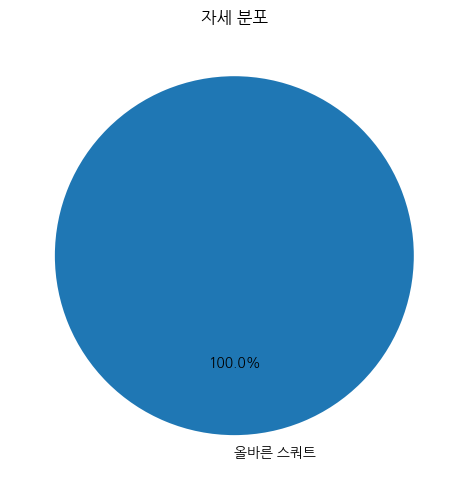

In [ ]:
print('📂 영상 파일을 선택하세요 (mp4, avi)')
uploaded_video = files.upload()

clf = SquatClassifier()

for filename, data in uploaded_video.items():
    with open(filename, 'wb') as f:
        f.write(data)

    print(f'\n[분석 중] {filename}')

    cap = cv2.VideoCapture(filename)
    if not cap.isOpened():
        print('❌ 영상 열기 실패')
        continue

    fps        = int(cap.get(cv2.CAP_PROP_FPS)) or 30
    total      = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    raw_path   = 'temp_output.mp4'
    final_path = 'final_output.mp4'

    writer = cv2.VideoWriter(raw_path,
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             fps, (960, 720))

    label_history = []
    smooth_buf    = deque(maxlen=5)
    rep_count     = 0
    squat_state   = 'UP'
    frame_idx     = 0

    with mp_pose.Pose(
        model_complexity=2,
        min_detection_confidence=0.7,
        min_tracking_confidence=0.7
    ) as pose:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_idx += 1
            if frame_idx % 30 == 0:
                print(f'  처리 중: {frame_idx}/{total} ({frame_idx/total*100:.1f}%)', end='\r')

            frame = cv2.resize(frame, (960, 720))
            h, w  = frame.shape[:2]

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            results = pose.process(rgb)
            rgb.flags.writeable = True

            if results.pose_landmarks:
                angles = extract_angles(results.pose_landmarks.landmark, w, h)

                if angles:
                    label, conf = clf.predict(angles)

                    # 스무딩
                    smooth_buf.append(label)
                    label_sm = Counter(smooth_buf).most_common(1)[0][0]
                    label_history.append(label_sm)

                    # 반복 카운트
                    k = angles['knee_angle_avg']
                    if squat_state == 'UP' and k < 62:
                        squat_state = 'DOWN'
                    elif squat_state == 'DOWN' and k > 72:
                        squat_state = 'UP'
                        rep_count  += 1

                    # 스켈레톤 + 각도 표시
                    draw_skeleton_and_angles(frame, results.pose_landmarks, angles)

                    # 오버레이 (label_sm 기준)
                    frame = draw_overlay(frame, angles, label_sm, conf)

                    # 반복 횟수 표시
                    cv2.putText(frame, f'Reps: {rep_count}',
                                (w-180, h-20),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                                (0,255,180), 2, cv2.LINE_AA)

                    # 상태 표시
                    cv2.putText(frame, squat_state,
                                (w-180, h-50),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                                (200,200,200), 1, cv2.LINE_AA)

            writer.write(frame)

    cap.release()
    writer.release()
    print(f'\n  ✅ 처리 완료 (총 {frame_idx}프레임)')

    # ffmpeg 변환
    print('🎬 ffmpeg 변환 중...')
    subprocess.run([
        'ffmpeg', '-y',
        '-i', raw_path,
        '-vcodec', 'libx264',
        '-acodec', 'aac',
        final_path
    ], capture_output=True)
    print('✅ 변환 완료:', final_path)

    # 요약
    if label_history:
        cnt = Counter(label_history)
        print(f'\n📊 영상 분석 요약 | 반복 횟수: {rep_count}회')
        print('─' * 35)
        for lbl, c in cnt.most_common():
            pct = c / len(label_history) * 100
            bar = '█' * int(pct // 5)
            print(f'  {LABEL_MAP[lbl]:<18} {bar} {pct:.1f}%')

        # 파이차트
        fig, ax = plt.subplots(figsize=(5,5))
        ax.pie(list(cnt.values()),
               labels=[LABEL_MAP[k] for k in cnt],
               autopct='%1.1f%%', startangle=90)
        ax.set_title('자세 분포')
        plt.tight_layout()
        plt.show()

    # 영상 표시
    video    = open(final_path, 'rb').read()
    data_url = 'data:video/mp4;base64,' + b64encode(video).decode()
    display(HTML(f'''
    <video width=600 controls>
        <source src="{data_url}" type="video/mp4">
    </video>
    '''))

CSV 저장

In [ ]:
!pip install xgboost > /dev/null 2>&1

# =============================================
# [셀 추가] zip 업로드 + 압축 해제 + 이미지 CSV 저장
# =============================================
import os, cv2, numpy as np, pandas as pd, zipfile
from google.colab import files

# zip 업로드 + 압축 해제
print('📂 Dataset zip 파일을 업로드하세요')
uploaded_zip = files.upload()
zip_name = list(uploaded_zip.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/Dataset')
print('✅ 압축 해제 완료')

DATASET_PATH = '/content/Dataset'

FOLDER_LABEL_MAP = {
    'Good':     0,
    'Bad_Back': 2,
    'Bad_Heel': 4,
}

rows = []

with mp_pose.Pose(static_image_mode=True,
                  min_detection_confidence=0.7,
                  model_complexity=2) as pose:

    for folder, label in FOLDER_LABEL_MAP.items():
        folder_path = os.path.join(DATASET_PATH, folder)
        if not os.path.exists(folder_path):
            print(f'❌ 폴더 없음: {folder_path}')
            continue

        img_files = [f for f in os.listdir(folder_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f'📁 {folder} ({label}번) : {len(img_files)}장 처리 중...')

        for fname in img_files:
            img = cv2.imread(os.path.join(folder_path, fname))
            if img is None:
                continue
            h, w = img.shape[:2]
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)

            if not results.pose_landmarks:
                continue

            angles = extract_angles(results.pose_landmarks.landmark, w, h)
            if not angles:
                continue

            row = {c: angles[c] for c in FEATURE_COLS}
            row['label'] = label
            rows.append(row)

df_image = pd.DataFrame(rows)
df_image.to_csv('csv_image_dataset.csv', index=False)
print(f'\n✅ 이미지 CSV 저장 완료: {len(df_image)}행')
print(df_image['label'].value_counts())

📂 Dataset zip 파일을 업로드하세요


Saving Dataset.zip to Dataset.zip
✅ 압축 해제 완료
❌ 폴더 없음: /content/Dataset/Good
❌ 폴더 없음: /content/Dataset/Bad_Back
❌ 폴더 없음: /content/Dataset/Bad_Heel

✅ 이미지 CSV 저장 완료: 0행


KeyError: 'label'

In [ ]:
import os, cv2, numpy as np, pandas as pd

FOLDER_LABEL_MAP = {
    'train/Good':     0,
    'train/Bad back': 2,
    'train/Bad heel': 4,
    'test/Good':      0,
    'test/Bad Back':  2,
    'test/Bad Heel':  4,
}

rows = []

with mp_pose.Pose(static_image_mode=True,
                  min_detection_confidence=0.7,
                  model_complexity=2) as pose:

    for folder, label in FOLDER_LABEL_MAP.items():
        folder_path = os.path.join('/content/Dataset', folder)
        if not os.path.exists(folder_path):
            print(f'❌ 폴더 없음: {folder_path}')
            continue

        img_files = [f for f in os.listdir(folder_path)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))]
        print(f'📁 {folder} ({label}번) : {len(img_files)}장 처리 중...')

        for fname in img_files:
            img = cv2.imread(os.path.join(folder_path, fname))
            if img is None:
                continue
            h, w = img.shape[:2]
            rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)

            if not results.pose_landmarks:
                continue

            angles = extract_angles(results.pose_landmarks.landmark, w, h)
            if not angles:
                continue

            row = {c: angles[c] for c in FEATURE_COLS}
            row['label'] = label
            rows.append(row)

df_image = pd.DataFrame(rows)
df_image.to_csv('csv_image_dataset.csv', index=False)
print(f'\n✅ 이미지 CSV 저장 완료: {len(df_image)}행')
print(df_image['label'].value_counts())

📁 train/Good (0번) : 1001장 처리 중...
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=LEFT, 무릎=68.6, 엉덩이=82.7, 발목=131.7
  [디버그] side=LEFT, 무릎=81.1, 엉덩이=75.5, 발목=72.7
  [디버그] side=LEFT, 무릎=71.6, 엉덩이=70.0, 발목=78.4
  [디버그] side=LEFT, 무릎=86.5, 엉덩이=80.5, 발목=74.0
  [디버그] side=LEFT, 무릎=78.5, 엉덩이=77.0, 발목=83.9
  [디버그] side=RIGHT, 무릎=63.9, 엉덩이=57.1, 발목=80.0
  [디버그] side=LEFT, 무릎=80.9, 엉덩이=71.8, 발목=74.2
  [디버그] side=LEFT, 무릎=89.9, 엉덩이=92.0, 발목=81.5
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=LEFT, 무릎=65.5, 엉덩이=87.7, 발목=143.1
  [디버그] side=LEFT, 무릎=67.9, 엉덩이=58.7, 발목=71.9
  [디버그] side=LEFT, 무릎=67.2, 엉덩이=66.0, 발목=78.2
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=LEFT, 무릎=65.9, 엉덩이=88.9, 발목=132.9
  [디버그] side=LEFT, 무릎=68.0, 엉덩이=64.6, 발목=76.8
  [디버그] side=LEFT, 무릎=81.7, 엉덩이=71.1, 발목=88.8
  [디버그] side=RIGHT, 무릎=74.2, 엉덩이=64.6, 발목=84.6
  [디버그] side=LEFT, 무릎=70.8, 엉덩이=66.2, 발목=83.0
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side=LEFT, 무릎=65.2, 엉덩이=75.6, 발목=135.5
  [디버그] side=LEFT, 무릎=75.7, 엉덩이=69.6, 발목=82.4
  [디버그] side=RIG

In [ ]:
from google.colab import files
files.download('csv_image_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =============================================
# [셀 추가] 영상 → CSV 저장 (파일명으로 라벨 자동 구분)
# =============================================
from google.colab import files

print('📂 영상 파일을 모두 선택해서 업로드하세요')
uploaded_video = files.upload()

FILENAME_LABEL_MAP = {
    'shallow':   1,   # 얕은 스쿼트
    'knee':      3,   # 무릎 안쪽 꺾임
    'asymmetry': 5,   # 비대칭
}

FRAME_INTERVAL = 5  # 5프레임마다 1장 추출

rows_video = []

for filename, data in uploaded_video.items():
    with open(filename, 'wb') as f:
        f.write(data)

    # 파일명으로 라벨 자동 감지
    label = None
    for keyword, lbl in FILENAME_LABEL_MAP.items():
        if keyword in filename.lower():
            label = lbl
            break

    if label is None:
        print(f'⚠️ {filename} → 라벨 감지 실패! 파일명에 shallow/knee/asymmetry 포함시켜주세요')
        continue

    print(f'\n[처리 중] {filename} → 라벨 {label} ({LABEL_MAP[label]})')

    cap = cv2.VideoCapture(filename)
    if not cap.isOpened():
        print('❌ 영상 열기 실패')
        continue

    frame_idx = 0
    saved = 0

    with mp_pose.Pose(
        model_complexity=2,
        min_detection_confidence=0.7,
        min_tracking_confidence=0.7
    ) as pose:

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_idx += 1

            if frame_idx % FRAME_INTERVAL != 0:
                continue

            frame = cv2.resize(frame, (960, 720))
            h, w = frame.shape[:2]
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = pose.process(rgb)

            if not results.pose_landmarks:
                continue

            angles = extract_angles(results.pose_landmarks.landmark, w, h)
            if not angles:
                continue

            row = {c: angles[c] for c in FEATURE_COLS}
            row['label'] = label
            rows_video.append(row)
            saved += 1

    cap.release()
    print(f'✅ {filename}: {saved}행 추출 완료')

df_video = pd.DataFrame(rows_video)
df_video.to_csv('csv_video_dataset.csv', index=False)
print(f'\n✅ 영상 CSV 저장 완료: {len(df_video)}행')
print(df_video['label'].value_counts())

📂 영상 파일을 모두 선택해서 업로드하세요


Saving asymmetry.mp4 to asymmetry.mp4
Saving knee.mp4 to knee.mp4
Saving shallow_1.mp4 to shallow_1.mp4
Saving shallow_2.mp4 to shallow_2.mp4

[처리 중] asymmetry.mp4 → 라벨 5 (비대칭 스쿼트)
  [디버그] side=RIGHT, 무릎=164.4, 엉덩이=137.3, 발목=134.8
  [디버그] side=LEFT, 무릎=173.2, 엉덩이=136.7, 발목=153.9
  [디버그] side=LEFT, 무릎=178.3, 엉덩이=138.9, 발목=156.7
  [디버그] side=LEFT, 무릎=179.7, 엉덩이=140.2, 발목=157.1
  [디버그] side=LEFT, 무릎=179.6, 엉덩이=140.6, 발목=157.3
  [디버그] side=LEFT, 무릎=178.9, 엉덩이=140.9, 발목=157.3
  [디버그] side=LEFT, 무릎=177.9, 엉덩이=139.0, 발목=155.3
  [디버그] side=LEFT, 무릎=162.3, 엉덩이=130.1, 발목=146.2
  [디버그] side=LEFT, 무릎=141.4, 엉덩이=119.0, 발목=134.4
  [디버그] side=RIGHT, 무릎=117.4, 엉덩이=120.5, 발목=109.0
  [디버그] side=RIGHT, 무릎=103.6, 엉덩이=111.7, 발목=102.5
  [디버그] side=RIGHT, 무릎=92.2, 엉덩이=103.6, 발목=97.5
  [디버그] side=RIGHT, 무릎=82.8, 엉덩이=94.9, 발목=95.4
  [디버그] side=RIGHT, 무릎=75.7, 엉덩이=89.9, 발목=92.2
  [디버그] side=RIGHT, 무릎=70.3, 엉덩이=83.5, 발목=92.3
  [디버그] side=RIGHT, 무릎=67.4, 엉덩이=80.1, 발목=93.9
  [보정] 무릎-엉덩이 y좌표 역전 감지 → 교환
  [디버그] side

In [ ]:
files.download('csv_video_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()  # csv_image_dataset.csv, csv_video_dataset.csv 두 개 한번에 선택

Saving csv_video_dataset.csv to csv_video_dataset (1).csv
Saving csv_image_dataset.csv to csv_image_dataset (1).csv


In [ ]:
# =============================================
# [셀 추가] CSV 합치기 + ML 학습
# =============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import joblib, os

# CSV 합치기
df1 = pd.read_csv('csv_image_dataset.csv')
df2 = pd.read_csv('csv_video_dataset.csv')

# 영상 데이터 증강 (각도값에 노이즈 추가)
def augment_angles(df, n=5):
    aug_rows = []
    for _, row in df.iterrows():
        for _ in range(n):
            new_row = row.copy()
            for col in FEATURE_COLS:
                new_row[col] = row[col] + np.random.normal(0, 1.5)
            aug_rows.append(new_row)
    return pd.DataFrame(aug_rows)

df2_aug = augment_angles(df2, n=5)
df2 = pd.concat([df2, df2_aug], ignore_index=True)
print(f'증강 후 영상 데이터: {len(df2)}행')

df = pd.concat([df1, df2], ignore_index=True).dropna()

print(f'✅ 전체 데이터: {len(df)}행')
print(df['label'].value_counts().sort_index())

X = df[FEATURE_COLS].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

os.makedirs('models', exist_ok=True)

# --- RandomForest ---
print('\n🌲 RandomForest 학습 중...')
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f'✅ RandomForest 정확도: {rf_acc*100:.2f}%')
print(classification_report(y_test, rf_pred,
      target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))

joblib.dump(rf, 'models/random_forest.pkl')

scaler_rf = StandardScaler()
scaler_rf.fit(X_train)
joblib.dump(scaler_rf, 'models/random_forest_scaler.pkl')

# --- XGBoost ---
print('\n⚡ XGBoost 학습 중...')
scaler_xgb = StandardScaler()
X_train_sc = scaler_xgb.fit_transform(X_train)
X_test_sc  = scaler_xgb.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42
)
xgb_model.fit(X_train_sc, y_train)
xgb_pred = xgb_model.predict(X_test_sc)
xgb_acc  = accuracy_score(y_test, xgb_pred)
print(f'✅ XGBoost 정확도: {xgb_acc*100:.2f}%')
print(classification_report(y_test, xgb_pred,
      target_names=[LABEL_MAP[i] for i in sorted(LABEL_MAP)]))

joblib.dump(xgb_model, 'models/xgboost.pkl')
joblib.dump(scaler_xgb, 'models/xgboost_scaler.pkl')

# --- 비교 요약 ---
print('\n📊 모델 정확도 비교')
print('─' * 30)
print(f'룰 기반         : 기준선')
print(f'RandomForest    : {rf_acc*100:.2f}%')
print(f'XGBoost         : {xgb_acc*100:.2f}%')
print('─' * 30)
print('✅ 모델 저장 완료 → models/ 폴더')

증강 후 영상 데이터: 1032행
✅ 전체 데이터: 4621행
label
0.0    1309
1.0     618
2.0    1112
3.0     192
4.0    1168
5.0     222
Name: count, dtype: int64

🌲 RandomForest 학습 중...
✅ RandomForest 정확도: 96.43%
              precision    recall  f1-score   support

     올바른 스쿼트       0.93      0.99      0.96       262
      얕은 스쿼트       0.97      0.97      0.97       124
앞으로 기울어진 스쿼트       1.00      0.96      0.97       223
    무릎 안쪽 꺾임       1.00      1.00      1.00        38
     발뒤꿈치 들림       0.97      0.94      0.95       234
     비대칭 스쿼트       0.98      0.98      0.98        44

    accuracy                           0.96       925
   macro avg       0.97      0.97      0.97       925
weighted avg       0.97      0.96      0.96       925


⚡ XGBoost 학습 중...
✅ XGBoost 정확도: 97.30%
              precision    recall  f1-score   support

     올바른 스쿼트       0.95      0.98      0.97       262
      얕은 스쿼트       0.98      0.98      0.98       124
앞으로 기울어진 스쿼트       0.99      0.96      0.98       223
    무릎 안쪽

In [ ]:
from google.colab import files

# 합친 CSV 저장
df.to_csv('csv_final_dataset.csv', index=False)

# 다운로드
files.download('csv_final_dataset.csv')
files.download('models/random_forest.pkl')
files.download('models/random_forest_scaler.pkl')
files.download('models/xgboost.pkl')
files.download('models/xgboost_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>